In [8]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [9]:
data = pd.read_csv('../datasets/rs_lettland.csv')
len(data)

1900

In [10]:
def topk_per_d_per_method(data, config_cols, k=5):
    """
    Return up to the top-k configs per group, ranked by avg_rmse.
    Averages are computed across seeds.
    """
    df = pd.read_csv(data, index_col = [0]) if isinstance(data, str) else data.copy()
    df = df.sort_values(by = ['target_instances', 'd', 'seed'])

    agg = (df.groupby(config_cols, as_index=False)
            .agg(avg_rmse=('val_rmse','mean'),
                avg_mae=('val_mae','mean'),
                n_seeds=('seed','nunique')))
    agg = agg.merge(df, how = 'right')
    agg = agg.sort_values(by = 'avg_rmse')
    topk_df = agg.groupby(['d', 'target_instances'], group_keys=False).head(k)
    topk_d = topk_df[['d', 'target_instances', 'method', 'avg_rmse', 'rmse', 'mae']]
    return topk_d, topk_df




In [11]:
mlp_data = pd.read_csv('../results/MLP_ablation_friedman.csv')
mlp_data['method'] = 'Finetuned MLP'
print(len(mlp_data))
mlp_data = mlp_data.drop_duplicates()
print(len(mlp_data))

tradaboost_data = pd.read_csv('../results/trada_ablation_friedman.csv')
tradaboost_data['method'] = 'TradaBost.R2'

2407
2407


C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_8592\2789320555.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  xgboost_data['method'] = 'XGBoost'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_8592\2789320555.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  naive_transfer_data_with_dummy['method'] = ' Naïve XGBoost'


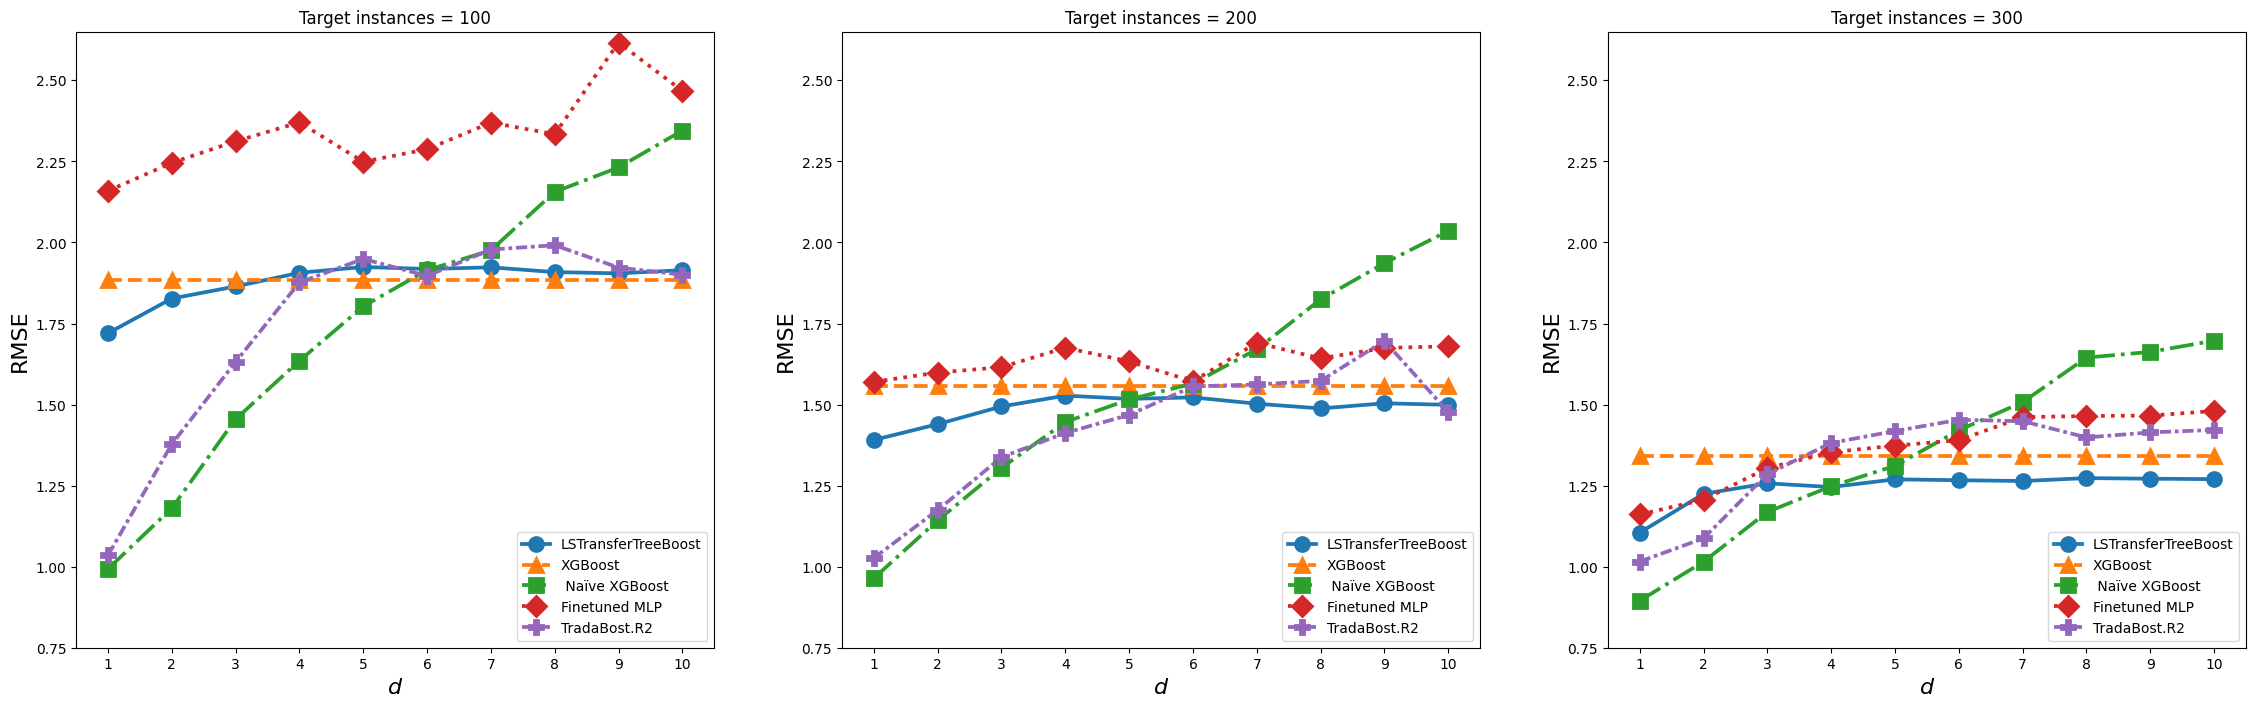

In [17]:
target_instances = 300
best_LSTransferTreeBoost, best_params_for_us = topk_per_d_per_method(
    f'../results/LSTransferTreeBoost_ablation_friedman.csv',
['target_instances', 'd', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=5
)
data = pd.read_csv('results/xgboost_ablation_friedman.csv')
xgboost_data = data[data['method'] == 'xgboost']
xgboost_data['method'] = 'XGBoost'
naive_transfer_data = data[data['method'] == 'xgboost_naive_transfer']
naive_transfer_data_with_dummy = data[data['method'] == 'xgboost_naive_transfer_with_dummy']
naive_transfer_data_with_dummy['method'] = ' Naïve XGBoost'

best_XGBoost, _ = topk_per_d_per_method(
    xgboost_data,
['target_instances', 'd', 'v', 'target_tree_size'], k=5
)

"""
best_naive_transfer, _ = topk_per_d_per_method(
    naive_transfer_data,
['target_instances', 'd', 'v', 'target_tree_size'], k=5
)
"""

best_naive_transfer_with_dummy, _ = topk_per_d_per_method(
    naive_transfer_data_with_dummy,
['target_instances', 'd', 'v', 'target_tree_size'], k=5
)


best_mlp, _ = topk_per_d_per_method(
    mlp_data,
['target_instances', 'd', 'base_lr','fine_tuning_lr','dropout_rate','batch_norm'], k=5
)


best_tradaboost, _ = topk_per_d_per_method(
    tradaboost_data,
['target_instances', 'd', 'n_estimators','lr','tree_size'], k=5
)

target_instances_list = [100,200,300]
df = pd.concat([best_LSTransferTreeBoost, best_XGBoost])
#df = pd.concat([df, best_naive_transfer])
df = pd.concat([df, best_naive_transfer_with_dummy])
df = pd.concat([df, best_mlp])
df = pd.concat([df, best_tradaboost])
i=0
from matplotlib.lines import Line2D

plt.figure(figsize = (28,8))
for target_instances in target_instances_list:
    plt.subplot(1,3,i+1)
    sns.pointplot(data = df[df['target_instances'] == target_instances], x = 'd', y = 'rmse', hue = 'method', errorbar=None, 
                    markers=['o', '^', 's', 'D', 'P'], markersize=10, linestyles=['-', '--', '-.', ':', (0, (3, 1, 1, 1))])
        
    # grab the current legend
    handles, labels = plt.gca().get_legend_handles_labels()

    # rebuild legend with longer lines
    new_handles = []
    for h in handles:
        if isinstance(h, Line2D):
            new_handles.append(Line2D(
                [0], [0], 
                color=h.get_color(),
                linestyle=h.get_linestyle(),
                marker=h.get_marker(),
                markersize=10,
                linewidth=2,
            ))
        else:
            new_handles.append(h)

    plt.legend(new_handles, labels, handlelength=3, handletextpad=0.5)  # increase handlelength to "extend" line
    plt.legend(loc="lower right")
    plt.gca().set_xlabel('$d$', fontsize=16)
    plt.gca().set_ylabel('RMSE', fontsize=16)
    #plt.ylabel('RMSE')
    plt.title(f'Target instances = {target_instances}')
    plt.ylim([0.75,2.65])
    i+=1
plt.savefig('vizes/friedman.png', dpi = 300, bbox_inches = 'tight', pad_inches = 0.1)
plt.show()




<Axes: xlabel='d', ylabel='source_tree_size'>

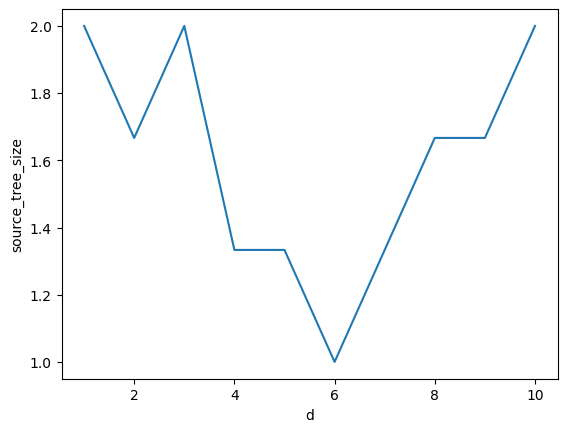

In [13]:
sns.lineplot(data = best_params_for_us, x = 'd', y = 'source_tree_size', errorbar=None)